# Decoding the Rhythms of Emotion: a Sentimental Journey Through Music Genres
## Notebook 1 of 4: Data Exploration

**Text Mining 2026/2027 | Group XX**
Raya Daher Alkhatib (20241416), Danyial Ahmad (20241831), Shaahir Racharla (20241419), Pedro Ambar (20231709)

| Notebook | Content |
|---|---|
| **01_eda** | Abstract, Introduction, Data Exploration |
| 02_preprocessing | Initial Preprocessing (writes the cleaned data) |
| 03_genre_classification | Genre Identification (text classification + Kaggle submission) |
| 04_sentiment_analysis | Sentiment Analysis, Conclusion |

Run order: 01 → 02 → 03/04. Notebook 1 only explores the data; notebook 2 writes `train_clean.pkl` and `test_clean.pkl`,
which notebooks 3 and 4 read. All raw files (`train.csv`, `test.csv`, `sample_submission.csv`) are expected in a `data/` folder next to the notebooks.

## Abstract



Song lyrics express the themes and emotions of an artist, and these are expected to vary between musical genres. Using a dataset of
about 135,000 songs labelled with six genres (pop, rap, rock, R&B, country and misc), this project investigates two questions: can a
song's genre be identified from its lyrics alone, and how does the emotional tone of lyrics differ across genres, over time and with
popularity? Our hypothesis was that genres with a distinctive vocabulary, such as rap and country, would be easy to recognise, while
pop, rock and R&B would be confused, and that rap and rock would be the most negative genres. After exploring the data, we cleaned the
lyrics and converted section annotations (e.g. [Chorus], [Hook]) into tokens. For genre identification we compared several text
representations and classifiers; the best model, a class-balanced linear SVM on TF-IDF unigrams and bigrams, reached a macro F1 of
0.55 (66.6% accuracy) in 5-fold cross-validation, with rap classified almost perfectly and most errors caused by songs predicted as
pop. For sentiment, we scored every lyric line with VADER and aggregated the scores per song. *(Main sentiment result per genre.)*
*(Result over time.)* *(Result on popularity.)* *(Result of the profanity test: how much of rap's negativity comes from profanity, which VADER
treats as negative.)* We conclude that lyrics carry a clear but limited genre signal, and that lexicon-based sentiment reveals
meaningful differences between genres that should be read with its vocabulary biases in mind.

## I. Introduction

Lyrics carry a large part of what a song "says". This project uses Natural Language Processing on ~135k songs to answer two questions:

1. **Genre identification**: can we predict the main genre of a song (pop, rap, rock, R&B, country, misc) from its lyrics alone?
2. **Sentiment analysis**: what emotional tone dominates each genre, has it changed over time, and is it related to how popular a song is?

**Related work.** Lyrics-based genre classification is a known and difficult task. Mayer, Neumayer & Rauber (2008) showed that
bag-of-words features can be complemented by rhyme and style features (e.g. word counts, repetition). Fell & Sporleder (2014)
found that genres such as rap are much easier to separate than pop/rock, which share vocabulary. Tsaptsinos (2017) used
hierarchical attention networks and still reported modest accuracies on many-genre problems, so we expect **rap to be easy and
pop vs. rock vs. R&B to be confused**. On the sentiment side, DeWall et al. (2011) and Brand, Acerbi & Mesoudi (2019) found that
popular-song lyrics became more negative over the last decades; we will check whether our data shows the same trend.

*References (verify before submitting):*
- Mayer, R., Neumayer, R., & Rauber, A. (2008). Rhyme and style features for musical genre classification by song lyrics. *ISMIR 2008*.
- Fell, M., & Sporleder, C. (2014). Lyrics-based analysis and classification of music. *COLING 2014*.
- Tsaptsinos, A. (2017). Lyrics-based music genre classification using a hierarchical attention network. *ISMIR 2017*.
- DeWall, C. N., Pond, R. S., Campbell, W. K., & Twenge, J. M. (2011). Tuning in to psychological change. *Psychology of Aesthetics, Creativity, and the Arts*, 5(3).
- Brand, C. O., Acerbi, A., & Mesoudi, A. (2019). Cultural evolution of emotional expression in 50 years of song lyrics. *Evolutionary Human Sciences*, 1.
- Hutto, C. J., & Gilbert, E. (2014). VADER: A parsimonious rule-based model for sentiment analysis of social media text. *ICWSM 2014*.

## II. Data Exploration

In [8]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 80)



_candidates = [Path("data"), Path("../data"), Path(".")]
DATA = next((p for p in _candidates if (p / "train.csv").exists()), None)
if DATA is None:
    raise FileNotFoundError("train.csv not found. Put train.csv and test.csv in a folder called 'data' "
                            "in the same folder as this notebook. Current folder: " + str(Path.cwd()))
print("Reading data from:", DATA)
GENRE_ORDER = ["pop", "rap", "rock", "rb", "misc", "country"]

Reading data from: data


In [3]:
train = pd.read_csv(DATA / "train.csv")
test = pd.read_csv(DATA / "test.csv")
print("train:", train.shape, "| test:", test.shape)
train.head(3)

train: (134967, 8) | test: (33742, 7)


,title,tag,artist,year,views,features,lyrics,id
0,Walk Away,rock,Tony Molina,2013,699,{},When you said you loved me\nDid you mean it then\nDid you change your mind o...,535805
1,Gotta Make It Kid Naruto Rap,rap,Reece Lett,2021,4,{Sl!ck},Kid Naruto Rap\n[Hook]\nEverybody wants you to hurt\nEverybody wants you to ...,7519483
2,​this is what i asked for,pop,Elliot (DNK),2019,389,{},[Verse 1]\nPeople tell me I've changed\nI find it hard to explain\nMaybe I f...,4892808


In [4]:
train.info()
print("\nMissing values (train):\n", train.isna().sum()[lambda s: s > 0])
print("Missing values (test):", test.isna().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134967 entries, 0 to 134966
Data columns (total 8 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   title     134965 non-null  object
 1   tag       134967 non-null  object
 2   artist    134967 non-null  object
 3   year      134967 non-null  int64 
 4   views     134967 non-null  int64 
 5   features  134967 non-null  object
 6   lyrics    134967 non-null  object
 7   id        134967 non-null  int64 
dtypes: int64(3), object(5)
memory usage: 8.2+ MB

Missing values (train):
 title    2
dtype: int64
Missing values (test): 0


The data is complete except for 2 missing titles, which we don't use. Test has the same columns minus `tag`.

### 1. Target: genre distribution

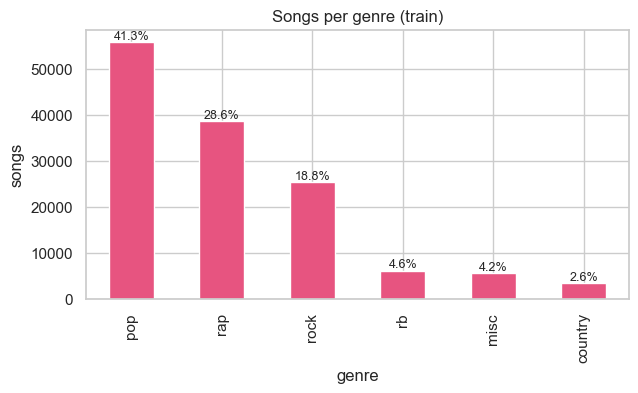

In [5]:
counts = train["tag"].value_counts()
ax = counts.plot.bar(color="#e75480", figsize=(7, 3.5))
for i, v in enumerate(counts):
    ax.text(i, v, f"{v/len(train):.1%}", ha="center", va="bottom", fontsize=9)
ax.set_title("Songs per genre (train)")
ax.set_xlabel("genre")
ax.set_ylabel("songs")
plt.show()

**Insight:** the classes are very imbalanced: pop + rap are ~70% of the data while country is only 2.6%.
A model that always says "pop" already gets 41% accuracy, so accuracy alone is misleading.
We will evaluate with **macro F1** (every genre weighs the same) and use class weighting during training.

### 2. Year and views

We first check whether the release years are plausible.

In [5]:
train["year"].describe().round(1)

    

count    134967.0
mean       2009.5
std          46.3
min           1.0
25%        2008.0
50%        2015.0
75%        2019.0
max        2024.0
Name: year, dtype: float64

The minimum year is 1, which is not a plausible release year. It is most likely a placeholder for an unknown year. We check how many songs have this value, and how many have years before 1900

In [6]:
print("Songs with year < 1900:", (train["year"] < 1900).sum())
print("Songs with year == 1:", (train["year"] == 1).sum())

Songs with year < 1900: 653
Songs with year == 1: 45


In [7]:
train[train["year"] < 1900].sample(5, random_state=0)[["title", "artist", "year", "tag"]]

,title,artist,year,tag
112007,OuterSpace,Lilvruno,1347,rap
101700,In Which the History Is Farther Continued,Henry Fielding,1749,misc
4213,A Treatise of Human Nature Chap. 1.4.7,David Hume,1738,misc
51259,Michael Robartes bids his Beloved be at Peace,William Butler Yeats,1899,misc
18407,Twelfth Night Act 1 Scene 1,William Shakespeare,1602,misc


Some years are clearly wrong (year = 1) and the very old ones are mostly `misc` texts (letters, poems), not songs.
This doesn't affect classification (we only use lyrics) but it matters for the "sentiment over time" analysis.
In notebook 2 we mark years before 1900 as unknown and later restrict time analyses to decades with enough songs.

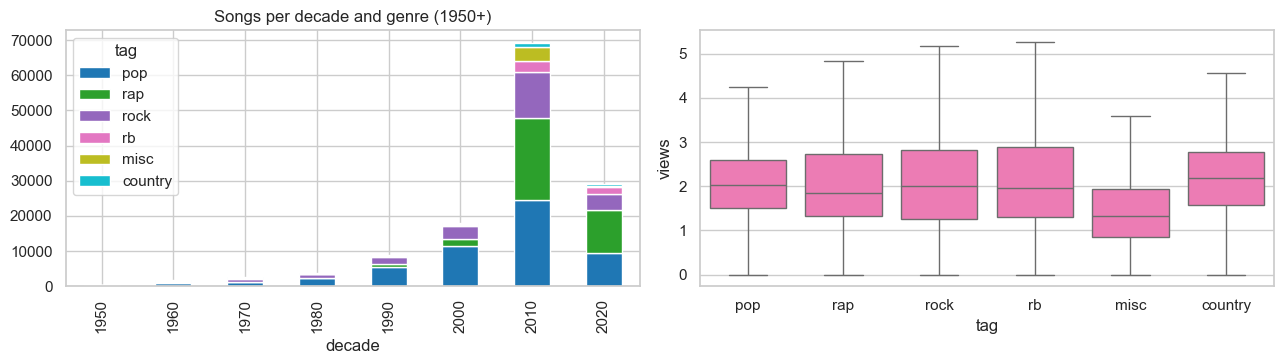

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
dec = (train.loc[train.year >= 1950, "year"] // 10 * 10)
pd.crosstab(dec, train.loc[train.year >= 1950, "tag"])[GENRE_ORDER].plot.bar(stacked=True, ax=axes[0], colormap="tab10")
axes[0].set_title("Songs per decade and genre (1950+)"); axes[0].set_xlabel("decade")
sns.boxplot(data=train, x="tag", y=np.log10(train["views"] + 1), order=GENRE_ORDER, ax=axes[1], showfliers=False, color="hotpink")
plt.tight_layout(); plt.show()

**Insights:**
- Most songs are from the 2010s; anything before the 1980s is a small sample. Trend analyses before ~1980 will be noisy.
- `views` is extremely skewed (median 89, max 3.6M), so we will always use `log(views)` when relating sentiment to popularity.
  Rap and R&B songs get more views on this platform than rock or country.

### 3. Collaborations (`features`)

In [9]:
train["has_feat"] = train["features"] != "{}"
train.groupby("tag")["has_feat"].mean().loc[GENRE_ORDER].round(3).to_frame("share with featured artist")

,share with featured artist
tag,
pop,0.125
rap,0.298
rock,0.080
rb,0.211
misc,0.166
country,0.076


Featuring other artists is far more common in rap. It is not a lyric feature, so we don't use it for prediction (the brief asks to
predict genre from the lyrics), but it confirms that rap behaves differently from the rest.

### 4. The lyrics themselves    


In [7]:
print(train.loc[1, "lyrics"][:600])

Kid Naruto Rap
[Hook]
Everybody wants you to hurt
Everybody wants you to cry with your face In the dirt
Gotta put in time, gotta work
Everybody’s praying that I fall
But I gotta make it work

Everybody wants you to hurt
Everybody wants you to cry with your face In the dirt
Gotta put in time, gotta work
Everybody’s praying that I fall
But I gotta make it

[Verse]
Hoping it might work out one day
Wrong
Do it yourself or you might as well fall
Gotta do the grind
If you never wanna fall
Better Aim for the top or you never won at all
As a kid I had nobody
Grew up parentless
Had to go and be funny
H


In [11]:
train["n_words"] = train["lyrics"].str.split().str.len()
train["n_lines"] = train["lyrics"].str.count("\n") + 1
train["has_sections"] = train["lyrics"].str.contains(r"\[", regex=True)
uniq = train["lyrics"].str.lower().str.findall(r"[a-z']+").map(lambda w: len(set(w)) / max(len(w), 1))
train["unique_ratio"] = uniq

summary = train.groupby("tag")[["n_words", "n_lines", "unique_ratio", "has_sections"]].median().loc[GENRE_ORDER]
summary["has_sections"] = train.groupby("tag")["has_sections"].mean().loc[GENRE_ORDER]
summary.round(2)

,n_words,n_lines,unique_ratio,has_sections
tag,,,,
pop,205.0,38.0,0.42,0.33
rap,415.0,61.0,0.44,0.70
rock,188.0,37.0,0.46,0.40
rb,291.0,54.0,0.36,0.64
misc,258.0,29.0,0.51,0.21
country,217.0,37.0,0.43,0.53


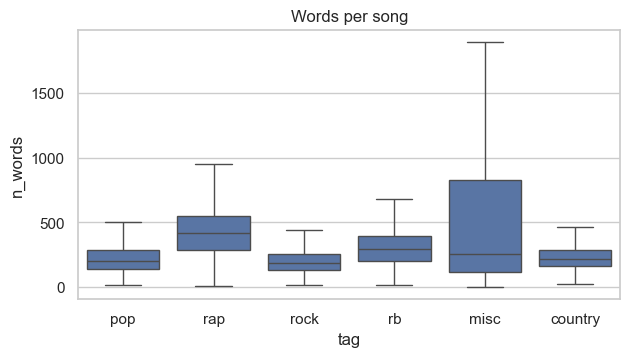

In [12]:
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.boxplot(data=train, x="tag", y="n_words", order=GENRE_ORDER, showfliers=False, ax=ax)
ax.set_title("Words per song"); plt.show()

**Insights:**
- Rap songs are about twice as long as pop, rock or country (median ~415 words vs ~200) and R&B is in between. Length alone is
  already a signal for rap. R&B has the *lowest* unique-word ratio: lots of repetition ("baby, baby, ooh").
- `misc` has the richest vocabulary and fewest lines, which fits the fact that many of these texts are prose, not songs.
- Only ~46% of songs have section tags like `[Chorus]`, so we can't rely on them for every song, but where they exist they
  can be useful.

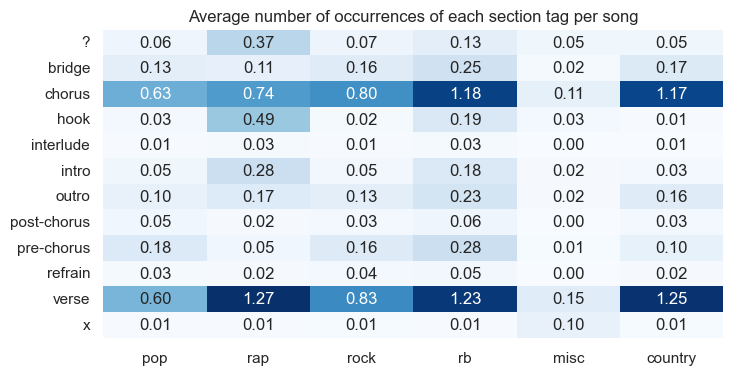

In [13]:
tags = (train.assign(section=train["lyrics"].str.findall(r"\[([^\]:\d]+)"))
        .explode("section").dropna(subset=["section"])[["section", "tag"]])
tags["section"] = tags["section"].str.strip().str.lower()
tags = tags[tags["section"].str.len() > 0]
top_tags = tags["section"].value_counts().head(12).index
tags = tags[tags["section"].isin(top_tags)].reset_index(drop=True)
tag_by_genre = pd.crosstab(tags["section"], tags["tag"]).div(train["tag"].value_counts(), axis=1)[GENRE_ORDER]
plt.figure(figsize=(8, 4))
sns.heatmap(tag_by_genre, annot=True, fmt=".2f", cmap="Blues", cbar=False)
plt.title("Average number of occurrences of each section tag per song"); plt.xlabel(""); plt.ylabel("")
plt.show()

**Insight:** the *type* of section is genre-dependent: `[Hook]` is almost exclusively rap vocabulary, while pop uses
`[Pre-Chorus]`/`[Post-Chorus]` more. So instead of throwing the tags away, we will **convert them into tokens** (e.g. `sec_hook`)
and let the classifier decide whether they help. This is done in notebook 2 and tested in notebook 3.

### 5. Most distinctive words per genre
To see what vocabulary separates genres, we compare each word's frequency inside a genre with its frequency in the rest of the
corpus (a smoothed log-ratio). Stopwords are removed here only to make the list readable.

In [14]:
sample = pd.concat([d.sample(min(len(d), 4000), random_state=1) for _, d in train.groupby("tag")])
cv = CountVectorizer(stop_words="english", min_df=20, token_pattern=r"(?u)\b[a-z][a-z']+\b")
X = cv.fit_transform(sample["lyrics"].str.lower().str.replace(r"\[[^\]]*\]", " ", regex=True))
vocab = np.array(cv.get_feature_names_out())
rows = {}
for g in GENRE_ORDER:
    m = (sample["tag"] == g).values
    in_g = np.asarray(X[m].sum(0)).ravel() + 1
    out_g = np.asarray(X[~m].sum(0)).ravel() + 1
    logratio = np.log(in_g / in_g.sum()) - np.log(out_g / out_g.sum())
    logratio[in_g < 50] = -np.inf          # ignore rare words
    rows[g] = vocab[np.argsort(-logratio)[:12]]
pd.DataFrame(rows)

,pop,rap,rock,rb,misc,country
0,hum,opps,greed,cherish,nbsp,redneck
1,ooo,opp,echoes,funk,madame,nerves
2,click,vibin,decay,nana,operations,honky
3,rum,perc,salvation,shoo,considerable,tonk
4,someone's,skrt,undone,bae,dost,heartaches
5,jingle,guap,nightmare,babe,sufficiently,fishin
6,rejoice,glizzy,crawl,mami,assent,peas
7,oceans,bando,void,rio,wherefore,gots
8,aah,aight,yay,ohhh,inquired,lonesome
9,awesome,grams,whispers,stranded,commerce,claus


**Insights:** rap is dominated by slang (*opps*, *skrt*, *guap*, *bando*), country by rural imagery (*redneck*, *honky tonk*,
*fishin*, *cowboy*, *lonesome*), rock by darker words (*decay*, *void*, *nightmare*, *screams*), R&B by romantic address
(*bae*, *babe*, *cherish*, *sexy*) and `misc` is clearly not music (*wherefore*, *dost*, *commerce*: old prose, plays, letters).
It also contains `nbsp`, an HTML leftover we clean in notebook 2. Pop's list is the least coherent (vocalisations like *ooo*, *aah*):
pop has no vocabulary of its own, so we expect it to be confused with the other genres.

### 6. Duplicates and language

In [15]:
print("Duplicated ids:", train["id"].duplicated().sum())
dup = train[train["lyrics"].duplicated(keep=False)]
print("Songs whose lyrics appear more than once:", len(dup))
print("...of which with conflicting genre:", dup.groupby("lyrics")["tag"].nunique().gt(1).sum(), "lyric texts")

EN_COMMON = {"the", "and", "you", "i", "to", "a", "me", "my", "it", "in", "of", "is"}
def english_ratio(text):
    words = re.findall(r"[a-z']+", text.lower())
    return sum(w in EN_COMMON for w in words) / max(len(words), 1)
train["en_ratio"] = train["lyrics"].map(english_ratio)
print("Share of songs that look non-English (ratio < 0.05): %.2f%%" % (100 * (train["en_ratio"] < 0.05).mean()))

Duplicated ids: 0
Songs whose lyrics appear more than once: 343
...of which with conflicting genre: 13 lyric texts
Share of songs that look non-English (ratio < 0.05): 0.14%


- There are a few duplicated lyrics (re-releases, covers); some even have different genres, which is label noise we can't fix.
  In notebook 2 we drop exact duplicates in train (keeping the first) so they don't leak between our training and validation splits.
- Almost all lyrics are English, so we use a single English pipeline and do not need language detection.

### Summary of EDA findings used in preprocessing

- Section tags (`[Chorus]`, `[Hook]`, ...) differ by genre → keep them as tokens.
- HTML leftovers (`nbsp`) and stage directions are present → remove.
- Years < 1900 are placeholders or non-songs → set to unknown.
- `views` is extremely skewed → use `log(views)`.
- Duplicate lyrics exist (some with conflicting genre) → drop duplicates in train only.
- Almost all lyrics are English → one English pipeline.

These decisions are implemented in **02_preprocessing**.